# Gesture Recognition — Preprocessing (All Gestures incl. Optionals)

Preprocesses raw MediaPipe pose CSVs for the **full gesture set** (7 classes):
- Mandatory: `idle`, `sl`, `sr`, `r_cw`
- O3: `r_ccw`
- O5: `su`, `sd`

**Pipeline:** Load → Label → Confidence filter → FPS normalize → Chest-center → Feature select → Velocity → EDA → Save

**Each teammate:** Change `PERSON_NAME`, then run all cells top to bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ---- Paths ----
BASE_PATH = Path("../data/csv_results")
POSES_PATH = BASE_PATH / "poses_with_ground_truth"
GROUND_TRUTH_PATH = BASE_PATH / "ground_truth"
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ---- Per-Person Config ----
PERSON_NAME = "nayana"   # <-- CHANGE THIS (arun / aswathy / nayana)

TARGET_FPS = 30

# ---- ALL gestures (mandatory + optional) ----
LABEL_MAP = {
    "idle": "idle",
    # Mandatory
    "swipe_left": "sl",
    "swipe_right": "sr",
    "rotate_clockwise": "r_cw",
    # O3
    "rotate_anticlockwise": "r_ccw",
    # O5
    "swipe_up": "su",
    "swipe_down": "sd",
}

print(f"Config: person={PERSON_NAME}, target_fps={TARGET_FPS}")
print(f"All labels: {list(LABEL_MAP.values())}")

Config: person=nayana, target_fps=30
All labels: ['idle', 'sl', 'sr', 'r_cw', 'r_ccw', 'su', 'sd']


## Step 1: Load Raw Pose Data

In [2]:
KNOWN_GESTURES = [
    "rotate_anticlockwise",
    "rotate_clockwise",
    "swipe_up",
    "swipe_down",
    "swipe_left",
    "swipe_right",
]

def parse_gesture_person_from_filename(fname):
    s = fname.lower().replace(".csv", "").replace("_poses", "")
    known_persons = ["arun", "aswathy", "nayana"]
    for person in known_persons:
        if s.startswith(person + "_"):
            return s[len(person) + 1:], person
    parts = s.split("_")
    return parts[0] if parts else "unknown", parts[-1] if len(parts) > 1 else "unknown"

def load_pose_data(file_path):
    df = pd.read_csv(file_path)
    gesture_from_name, person = parse_gesture_person_from_filename(file_path.name)
    df["person"] = person
    df["source_file"] = file_path.name
    if "ground_truth" in df.columns:
        df["gesture_type"] = df["ground_truth"].astype(str).str.lower()
    else:
        df["gesture_type"] = gesture_from_name
    return df

# Load all files for the current person
pose_files = sorted(POSES_PATH.glob(f"{PERSON_NAME}_*_poses.csv"))
print(f"Found {len(pose_files)} files for '{PERSON_NAME}':")

all_data = []
for f in pose_files:
    df = load_pose_data(f)
    all_data.append(df)
    print(f"  {f.name}: {len(df)} rows")

final_df = pd.concat(all_data, ignore_index=True)
print(f"\nCombined ({PERSON_NAME}): {len(final_df)} rows")
print(final_df["gesture_type"].value_counts())

Found 6 files for 'nayana':
  nayana_rotate_anticlockwise_poses.csv: 2999 rows


C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["person"] = person
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["source_file"] = file_path.name
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

  nayana_rotate_clockwise_poses.csv: 2970 rows
  nayana_swipe_down_poses.csv: 3064 rows


C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["person"] = person
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["source_file"] = file_path.name
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

  nayana_swipe_left_poses.csv: 2721 rows
  nayana_swipe_right_poses.csv: 2886 rows
  nayana_swipe_up_poses.csv: 2983 rows

Combined (nayana): 17623 rows
gesture_type
idle                    13981
rotate_anticlockwise      670
rotate_clockwise          655
swipe_right               633
swipe_down                586
swipe_left                578
swipe_up                  520
Name: count, dtype: int64


C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["person"] = person
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["source_file"] = file_path.name
C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\416771851.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

## Step 2: Label Mapping + Drop Unmapped

In [3]:
final_df["label"] = final_df["gesture_type"].str.strip().str.lower().map(LABEL_MAP)

before = len(final_df)
final_df = final_df[final_df["label"].notna()].reset_index(drop=True)
dropped = before - len(final_df)
print(f"Dropped {dropped} frames with unmapped labels ({dropped/before*100:.1f}%)")
print(f"Remaining: {len(final_df)} frames")
print(final_df["label"].value_counts())

Dropped 0 frames with unmapped labels (0.0%)
Remaining: 17623 frames
label
idle     13981
r_ccw      670
r_cw       655
sr         633
sd         586
sl         578
su         520
Name: count, dtype: int64


C:\Users\Aswathy\AppData\Local\Temp\ipykernel_24216\1500234824.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["label"] = final_df["gesture_type"].str.strip().str.lower().map(LABEL_MAP)


## Step 3: Confidence Filtering

In [4]:
CONFIDENCE_THRESHOLD = 0.5
CRITICAL_KEYPOINTS = [
    "left_wrist", "right_wrist",
    "left_elbow", "right_elbow",
    "left_shoulder", "right_shoulder",
]

confidence_cols = [f"{kp}_confidence" for kp in CRITICAL_KEYPOINTS
                   if f"{kp}_confidence" in final_df.columns]

low_conf_mask = (final_df[confidence_cols] < CONFIDENCE_THRESHOLD).any(axis=1)
n_low = low_conf_mask.sum()
print(f"Frames below threshold: {n_low} ({n_low/len(final_df)*100:.1f}%)")

before = len(final_df)
final_df = final_df[~low_conf_mask].reset_index(drop=True)
print(f"Removed: {before - len(final_df)} | Remaining: {len(final_df)}")

Frames below threshold: 2799 (15.9%)
Removed: 2799 | Remaining: 14824


## Step 4: FPS Normalization

In [5]:
def detect_fps(df):
    diffs = np.diff(df["time"].values)
    return round(1000.0 / np.median(diffs))

def resample_to_target_fps(df, target_fps, source_file_col="source_file"):
    resampled_parts = []
    for source_file, group in df.groupby(source_file_col):
        group = group.sort_values("time").reset_index(drop=True)
        source_fps = detect_fps(group)
        if abs(source_fps - target_fps) <= 5:
            resampled_parts.append(group)
        elif source_fps > target_fps:
            step = round(source_fps / target_fps)
            resampled_parts.append(group.iloc[::step].reset_index(drop=True))
        else:
            resampled_parts.append(group)
    return pd.concat(resampled_parts, ignore_index=True)

original_len = len(final_df)
final_df = resample_to_target_fps(final_df, TARGET_FPS)
print(f"FPS normalization: {original_len} -> {len(final_df)} frames")

FPS normalization: 14824 -> 5220 frames


## Step 5: Chest-Centered Normalization

In [6]:
def normalize_chest_centered(df):
    df = df.copy()
    cx = (df["left_shoulder_x"] + df["right_shoulder_x"]) / 2
    cy = (df["left_shoulder_y"] + df["right_shoulder_y"]) / 2
    cz = (df["left_shoulder_z"] + df["right_shoulder_z"]) / 2
    shoulder_width = np.sqrt(
        (df["left_shoulder_x"] - df["right_shoulder_x"])**2 +
        (df["left_shoulder_y"] - df["right_shoulder_y"])**2 +
        (df["left_shoulder_z"] - df["right_shoulder_z"])**2
    )
    shoulder_width = shoulder_width.replace(0, np.nan)
    coord_cols = [c for c in df.columns if c.endswith(("_x", "_y", "_z"))]
    for col in coord_cols:
        if col.endswith("_x"):
            df[col] = (df[col] - cx) / shoulder_width
        elif col.endswith("_y"):
            df[col] = (df[col] - cy) / shoulder_width
        elif col.endswith("_z"):
            df[col] = (df[col] - cz) / shoulder_width
    return df.dropna().reset_index(drop=True)

final_df = normalize_chest_centered(final_df)
print("After normalization:", final_df.shape)

After normalization: (5220, 138)


## Step 6: Feature Selection + Velocity

In [7]:
UPPER_BODY_PARTS = [
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_pinky", "right_pinky",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "nose",
]
SUFFIXES = ["_x", "_y", "_z"]

feature_cols = [p + s for p in UPPER_BODY_PARTS for s in SUFFIXES
                if p + s in final_df.columns]

def add_velocity_features(df, feature_cols):
    df = df.copy()
    velocity_cols = []
    for col in feature_cols:
        vel_col = col + "_vel"
        df[vel_col] = df.groupby("source_file")[col].diff().fillna(0)
        velocity_cols.append(vel_col)
    return df, velocity_cols

final_df, velocity_cols = add_velocity_features(final_df, feature_cols)
all_feature_cols = feature_cols + velocity_cols

print(f"Position: {len(feature_cols)} | Velocity: {len(velocity_cols)} | Total: {len(all_feature_cols)}")

Position: 45 | Velocity: 45 | Total: 90


## Step 7: EDA

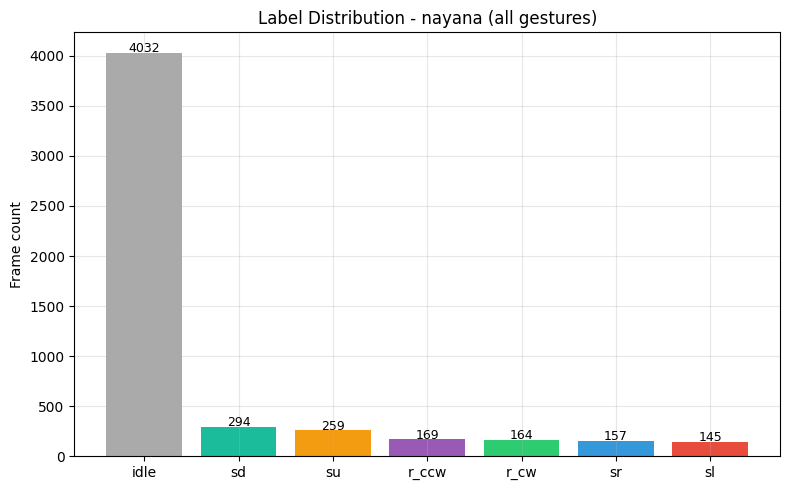

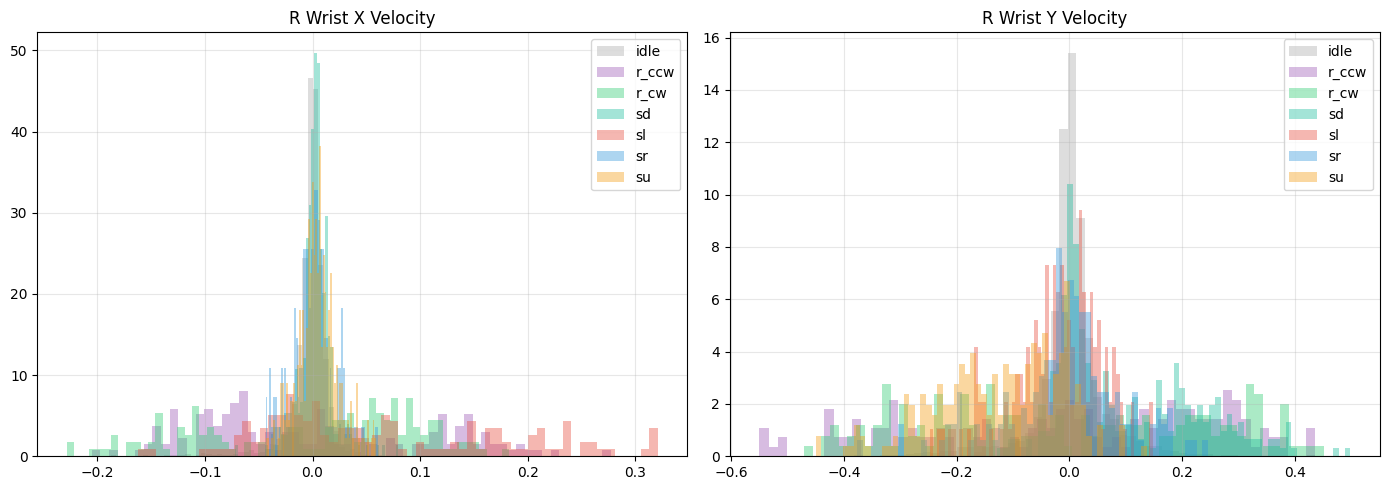

EDA saved to: C:\Users\Aswathy\Documents\jmu\WS25\ML Project\final_project_latest\final-submission\visualizations\eda\nayana_optionals


In [8]:
eda_dir = Path("../visualizations/eda") / (PERSON_NAME + "_optionals")
eda_dir.mkdir(parents=True, exist_ok=True)

GESTURE_COLORS = {
    "idle": "#aaaaaa", "sl": "#e74c3c", "sr": "#3498db",
    "r_cw": "#2ecc71", "r_ccw": "#9b59b6", "su": "#f39c12", "sd": "#1abc9c",
}

# Label distribution
fig, ax = plt.subplots(figsize=(8, 5))
label_counts = final_df["label"].value_counts()
colors = [GESTURE_COLORS.get(l, "#cccccc") for l in label_counts.index]
ax.bar(label_counts.index, label_counts.values, color=colors)
ax.set_title(f"Label Distribution - {PERSON_NAME} (all gestures)")
ax.set_ylabel("Frame count")
for bar, v in zip(ax.patches, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(eda_dir / "01_label_distribution_all.png"), dpi=150, bbox_inches="tight")
plt.show()

# Velocity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, grp in final_df.groupby("label"):
    c = GESTURE_COLORS.get(label, "#cccccc")
    axes[0].hist(grp["right_wrist_x_vel"].dropna(), bins=60, alpha=0.4,
                 color=c, label=label, density=True)
    axes[1].hist(grp["right_wrist_y_vel"].dropna(), bins=60, alpha=0.4,
                 color=c, label=label, density=True)
axes[0].set_title("R Wrist X Velocity"); axes[0].legend()
axes[1].set_title("R Wrist Y Velocity"); axes[1].legend()
plt.tight_layout()
plt.savefig(str(eda_dir / "02_velocity_all.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"EDA saved to: {eda_dir.resolve()}")

## Step 8: Save Preprocessed Data

In [9]:
cols_to_save = all_feature_cols + ["time", "label", "person", "source_file"]
df_to_save = final_df[cols_to_save].copy()

save_path = PROCESSED_DIR / f"{PERSON_NAME}_preprocessed.csv"
df_to_save.to_csv(save_path, index=False)

print(f"Saved preprocessed data for '{PERSON_NAME}':")
print(f"  Path: {save_path}")
print(f"  Shape: {df_to_save.shape}")
print(f"  Features: {len(all_feature_cols)}")
print(f"  Labels: {dict(df_to_save['label'].value_counts())}")
print(f"\nNote: Change PERSON_NAME above and re-run for each teammate.")

Saved preprocessed data for 'nayana':
  Path: ..\data\processed\nayana_preprocessed.csv
  Shape: (5220, 94)
  Features: 90
  Labels: {'idle': np.int64(4032), 'sd': np.int64(294), 'su': np.int64(259), 'r_ccw': np.int64(169), 'r_cw': np.int64(164), 'sr': np.int64(157), 'sl': np.int64(145)}

Note: Change PERSON_NAME above and re-run for each teammate.
